In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA

# For better plots
plt.rcParams["figure.figsize"] = (12,6)
sns.set_style("whitegrid")

In [2]:
# Generate date range
dates = pd.date_range(start="2015-01-01", periods=2000)

# Generate temperature with seasonality + noise
temperature = 25 + np.sin(np.arange(2000)/365 * 2*np.pi) * 10 + np.random.normal(0,2,2000)

# Generate rainfall
rainfall = np.random.randint(0,100,2000)

# Create DataFrame
df = pd.DataFrame({
    "date": dates,
    "temperature": temperature,
    "rainfall": rainfall
})

# Save dataset
df.to_csv("../data/raw/climate.csv", index=False)

df.head()

,date,temperature,rainfall
0,2015-01-01,27.831769,50
1,2015-01-02,24.152847,25
2,2015-01-03,28.202891,70
3,2015-01-04,27.071029,39
4,2015-01-05,26.422487,80


In [3]:
df = pd.read_csv("../data/raw/climate.csv")
df.head()

,date,temperature,rainfall
0,2015-01-01,27.831769,50
1,2015-01-02,24.152847,25
2,2015-01-03,28.202891,70
3,2015-01-04,27.071029,39
4,2015-01-05,26.422487,80


In [4]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Check missing values
print(df.isnull().sum())

# Fill missing values
df.fillna(method='ffill', inplace=True)

df.info()

date           0
temperature    0
rainfall       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2000 non-null   datetime64[ns]
 1   temperature  2000 non-null   float64       
 2   rainfall     2000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 47.0 KB


C:\Users\shwet\AppData\Local\Temp\ipykernel_23436\1684733838.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


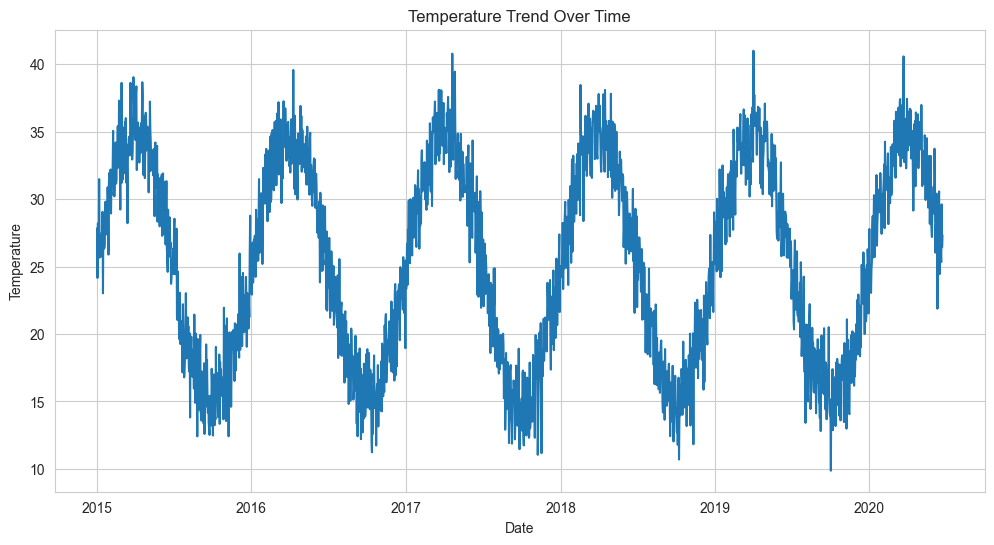

In [5]:
plt.plot(df['date'], df['temperature'])
plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

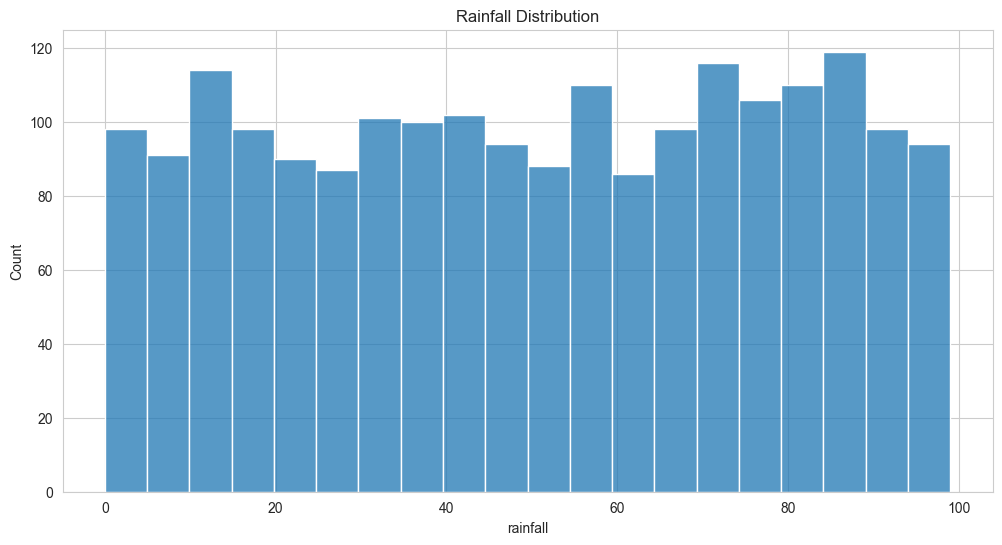

In [6]:
sns.histplot(df['rainfall'], bins=20)
plt.title("Rainfall Distribution")
plt.show()

In [7]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df.head()

,date,temperature,rainfall,year,month
0,2015-01-01,27.831769,50,2015,1
1,2015-01-02,24.152847,25,2015,1
2,2015-01-03,28.202891,70,2015,1
3,2015-01-04,27.071029,39,2015,1
4,2015-01-05,26.422487,80,2015,1


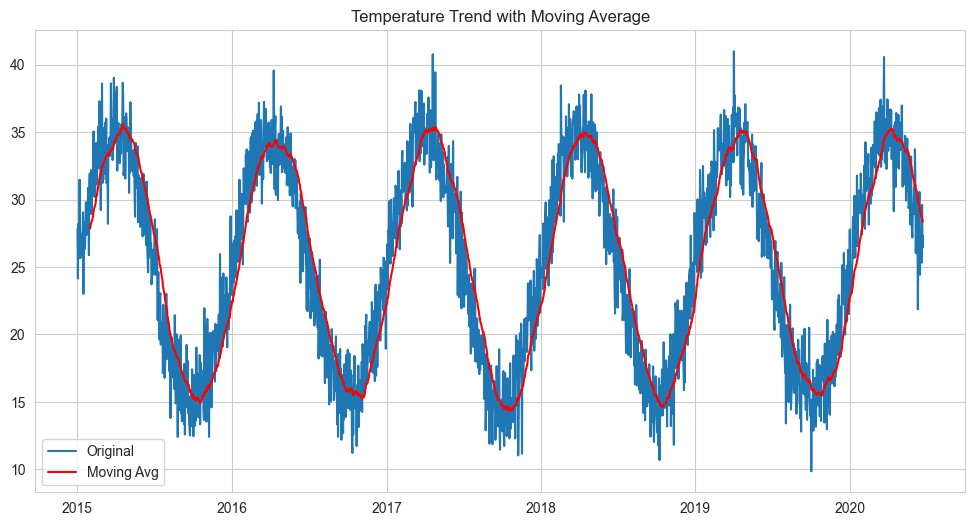

In [8]:
df['temp_ma'] = df['temperature'].rolling(window=30).mean()

plt.plot(df['date'], df['temperature'], label='Original')
plt.plot(df['date'], df['temp_ma'], label='Moving Avg', color='red')
plt.legend()
plt.title("Temperature Trend with Moving Average")
plt.show()

In [9]:
mean = df['temperature'].mean()
std = df['temperature'].std()

df['z_score'] = (df['temperature'] - mean)/std

df['anomaly'] = df['z_score'].apply(lambda x: 1 if abs(x) > 2 else 0)

df[df['anomaly'] == 1].head()

,date,temperature,rainfall,year,month,temp_ma,z_score,anomaly
840,2017-04-20,40.786351,85,2017,4,35.297776,2.086310,1
1376,2018-10-08,10.685222,83,2018,10,14.882826,-2.037954,1
1552,2019-04-02,41.003899,0,2019,4,33.990088,2.116117,1
1735,2019-10-02,9.854679,15,2019,10,16.039141,-2.151750,1
1907,2020-03-22,40.583137,34,2020,3,34.436037,2.058467,1


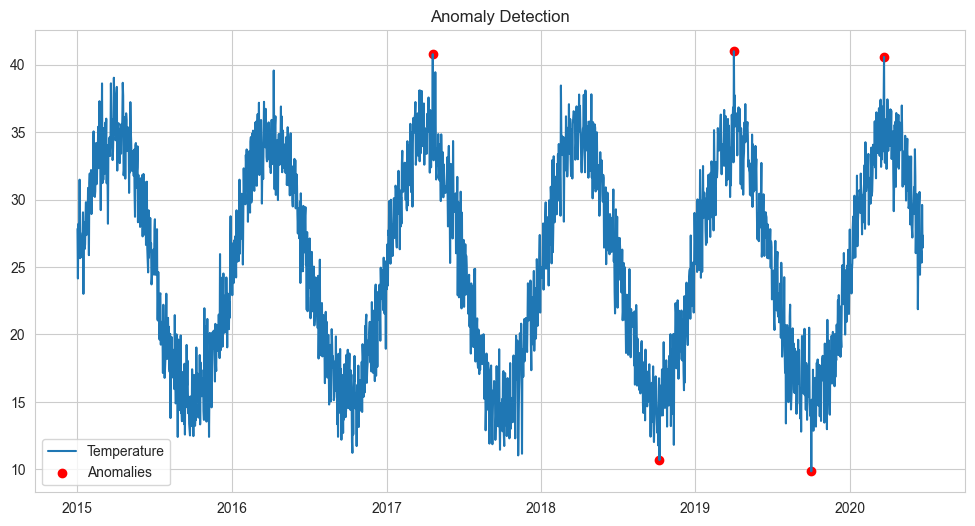

In [10]:
plt.plot(df['date'], df['temperature'], label='Temperature')

anomalies = df[df['anomaly'] == 1]
plt.scatter(anomalies['date'], anomalies['temperature'], color='red', label='Anomalies')

plt.legend()
plt.title("Anomaly Detection")
plt.show()

In [11]:
model = ARIMA(df['temperature'], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

print(forecast)

2000    27.115609
2001    27.131827
2002    27.130594
2003    27.130687
2004    27.130680
2005    27.130681
2006    27.130681
2007    27.130681
2008    27.130681
2009    27.130681
2010    27.130681
2011    27.130681
2012    27.130681
2013    27.130681
2014    27.130681
2015    27.130681
2016    27.130681
2017    27.130681
2018    27.130681
2019    27.130681
2020    27.130681
2021    27.130681
2022    27.130681
2023    27.130681
2024    27.130681
2025    27.130681
2026    27.130681
2027    27.130681
2028    27.130681
2029    27.130681
Name: predicted_mean, dtype: float64


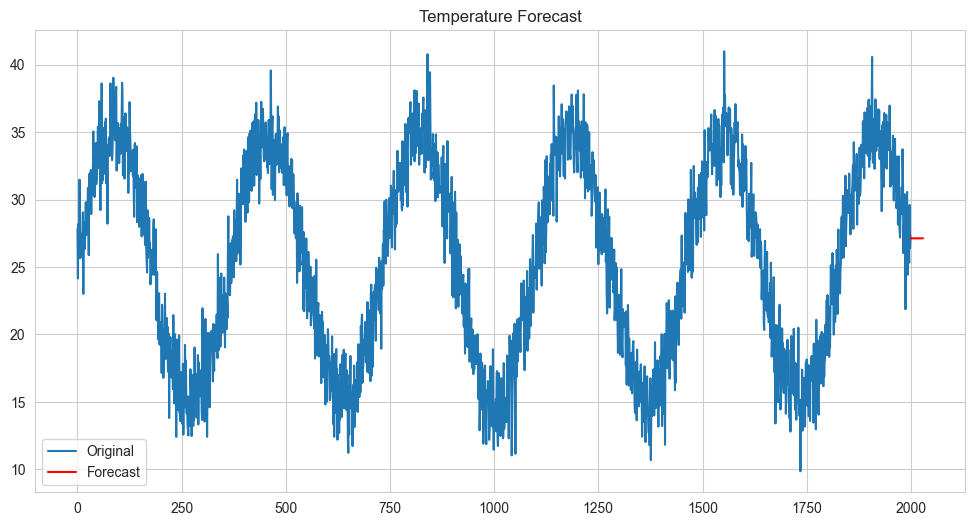

In [12]:
plt.plot(df['temperature'], label='Original')
plt.plot(range(len(df), len(df)+30), forecast, color='red', label='Forecast')

plt.legend()
plt.title("Temperature Forecast")
plt.show()

In [13]:
df.to_csv("../data/processed/processed_climate.csv", index=False)

plt.savefig("../outputs/graphs/final_plot.png")

<Figure size 1200x600 with 0 Axes>

In [14]:
print("Average Temperature:", df['temperature'].mean())
print("Max Temperature:", df['temperature'].max())
print("Total Anomalies:", df['anomaly'].sum())

Average Temperature: 25.55932315272263
Max Temperature: 41.00389924543413
Total Anomalies: 5


In [16]:
import pandas as pd
import numpy as np

def load_data():
    dates = pd.date_range("2015-01-01", periods=2500)

    temperature = (
        25 +
        np.sin(np.arange(2500)/365 * 2*np.pi) * 10 +
        np.random.normal(0, 2, 2500)
    )

    rainfall = np.random.randint(0, 100, 2500)

    df = pd.DataFrame({
        "date": dates,
        "temperature": temperature,
        "rainfall": rainfall
    })

    return df

SyntaxError: invalid syntax (829179109.py, line 1)